# RQ5 Gantt Charts — Serial vs Parallel Execution

This notebook creates **two Gantt charts** for the parallel-execution experiment:

1. **Without router**
   - Serial: `analyze_data → extract_chart_config → justify_chart_type`
   - Parallel: `analyze_data → [extract_chart_config || justify_chart_type]`

2. **With router**
   - Serial: `router → analyze_data → extract_chart_config → justify_chart_type`
   - Parallel: `router → analyze_data → [extract_chart_config || justify_chart_type]`

The notebook uses your existing `rq5_raw_results.csv` if available.  
If the file is not found, it uses fallback values from your RQ5 report so the charts can still be generated.


In [1]:
# ============================================================
# CELL 1 — Imports and path setup
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change this only if your file is stored somewhere else
POSSIBLE_RAW_RESULT_PATHS = [
    Path("rq5_consolidated_outputs/rq5_raw_results.csv"),
    Path("parallel_exec/rq5_consolidated_outputs/rq5_raw_results.csv"),
    Path("FINAL FOLDER/parallel_exec/rq5_consolidated_outputs/rq5_raw_results.csv"),
    Path("data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/parallel_exec/rq5_consolidated_outputs/rq5_raw_results.csv"),
    Path("/mnt/data/final_folder_unzipped/FINAL FOLDER/parallel_exec/rq5_consolidated_outputs/rq5_raw_results.csv"),
]

OUT_DIR = Path("rq5_gantt_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUT_DIR.resolve())


Output folder: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/parallel_exec/rq5_gantt_outputs


In [2]:
# ============================================================
# CELL 2 — Load RQ5 raw result file
# ============================================================

raw_path = None
for p in POSSIBLE_RAW_RESULT_PATHS:
    if p.exists():
        raw_path = p
        break

if raw_path is not None:
    print("Loaded raw results from:", raw_path)
    df = pd.read_csv(raw_path)
    display(df.head())
else:
    print("No rq5_raw_results.csv found.")
    print("Using fallback timing values from the RQ5 report.")
    df = None


Loaded raw results from: rq5_consolidated_outputs/rq5_raw_results.csv


,condition,t_router,t_analysis,t_config,t_type,t_parallel_wall,t_total,charttype,success,run,query_idx,query
0,serial_without_router,0.000000,15.689193,14.903082,7.482483,0.000000,38.074766,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
1,parallel_without_router,0.000000,12.731504,18.007769,3.762608,18.009108,30.740617,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
2,serial_with_router,2.702558,15.145074,17.172072,3.722018,0.000000,38.741747,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
3,parallel_with_router,3.746508,14.198481,15.862618,4.745508,15.863079,33.808075,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
4,serial_without_router,0.000000,14.599199,17.546654,3.433924,0.000000,35.579793,line,True,1,2,Show the monthly revenue trend as a line chart...


In [3]:
# ============================================================
# CELL 3 — Compute representative stage durations
# ============================================================

# We use MEDIAN stage times when raw data is available.
# This avoids rate-limit outliers dominating the Gantt chart.
#
# If raw data is not found, the fallback values below come from your RQ5 report:
# serial_without_router: analysis 13.82, config 45.18, type 4.20
# parallel_without_router: analysis 13.33, config 22.49, type 4.38, parallel wall 22.50
# serial_with_router: router 4.01, analysis 109.66, config 21.28, type 4.24
# parallel_with_router: router 4.29, analysis 15.23, config 24.37, type 4.39, parallel wall 24.37

FALLBACK = {
    "serial_without_router": {
        "router": 0.00,
        "analysis": 13.82,
        "config": 45.18,
        "type": 4.20,
        "parallel_wall": 0.00,
    },
    "parallel_without_router": {
        "router": 0.00,
        "analysis": 13.33,
        "config": 22.49,
        "type": 4.38,
        "parallel_wall": 22.50,
    },
    "serial_with_router": {
        "router": 4.01,
        "analysis": 109.66,
        "config": 21.28,
        "type": 4.24,
        "parallel_wall": 0.00,
    },
    "parallel_with_router": {
        "router": 4.29,
        "analysis": 15.23,
        "config": 24.37,
        "type": 4.39,
        "parallel_wall": 24.37,
    },
}

def get_stage_summary(df, condition):
    if df is None:
        return FALLBACK[condition]

    sub = df[df["condition"] == condition].copy()
    if sub.empty:
        print(f"Warning: condition {condition} not found. Using fallback.")
        return FALLBACK[condition]

    def median_or_zero(col):
        if col not in sub.columns:
            return 0.0
        return float(sub[col].fillna(0).median())

    return {
        "router": median_or_zero("t_router"),
        "analysis": median_or_zero("t_analysis"),
        "config": median_or_zero("t_config"),
        "type": median_or_zero("t_type"),
        "parallel_wall": median_or_zero("t_parallel_wall"),
    }

stage_summary = {
    condition: get_stage_summary(df, condition)
    for condition in [
        "serial_without_router",
        "parallel_without_router",
        "serial_with_router",
        "parallel_with_router",
    ]
}

stage_summary_df = pd.DataFrame(stage_summary).T.reset_index().rename(columns={"index": "condition"})
display(stage_summary_df.round(2))

stage_summary_df.to_csv(OUT_DIR / "rq5_gantt_stage_summary.csv", index=False)
print("Saved:", OUT_DIR / "rq5_gantt_stage_summary.csv")


,condition,router,analysis,config,type,parallel_wall
0,serial_without_router,0.00,13.70,18.85,3.82,0.00
1,parallel_without_router,0.00,12.42,19.58,3.59,19.58
2,serial_with_router,3.78,14.37,20.19,4.57,0.00
3,parallel_with_router,3.56,13.94,21.23,3.79,21.23


Saved: rq5_gantt_outputs/rq5_gantt_stage_summary.csv


In [4]:
# ============================================================
# CELL 4 — Build Gantt timeline rows
# ============================================================

def build_gantt_rows(condition, include_router):
    """
    Returns rows:
    label, stage, start, duration, end
    """
    s = stage_summary[condition]
    rows = []

    if "serial" in condition:
        t = 0.0

        if include_router:
            rows.append({
                "path": "Serial",
                "stage": "router",
                "start": t,
                "duration": s["router"],
                "end": t + s["router"],
            })
            t += s["router"]

        rows.append({
            "path": "Serial",
            "stage": "analyze_data",
            "start": t,
            "duration": s["analysis"],
            "end": t + s["analysis"],
        })
        t += s["analysis"]

        rows.append({
            "path": "Serial",
            "stage": "extract_chart_config",
            "start": t,
            "duration": s["config"],
            "end": t + s["config"],
        })
        t += s["config"]

        rows.append({
            "path": "Serial",
            "stage": "justify_chart_type",
            "start": t,
            "duration": s["type"],
            "end": t + s["type"],
        })

    else:
        t = 0.0

        if include_router:
            rows.append({
                "path": "Parallel",
                "stage": "router",
                "start": t,
                "duration": s["router"],
                "end": t + s["router"],
            })
            t += s["router"]

        rows.append({
            "path": "Parallel",
            "stage": "analyze_data",
            "start": t,
            "duration": s["analysis"],
            "end": t + s["analysis"],
        })
        t += s["analysis"]

        # Parallel part starts after analysis.
        parallel_start = t

        rows.append({
            "path": "Parallel",
            "stage": "extract_chart_config",
            "start": parallel_start,
            "duration": s["config"],
            "end": parallel_start + s["config"],
        })

        rows.append({
            "path": "Parallel",
            "stage": "justify_chart_type",
            "start": parallel_start,
            "duration": s["type"],
            "end": parallel_start + s["type"],
        })

    return rows


without_router_rows = (
    build_gantt_rows("serial_without_router", include_router=False)
    + build_gantt_rows("parallel_without_router", include_router=False)
)

with_router_rows = (
    build_gantt_rows("serial_with_router", include_router=True)
    + build_gantt_rows("parallel_with_router", include_router=True)
)

without_router_gantt = pd.DataFrame(without_router_rows)
with_router_gantt = pd.DataFrame(with_router_rows)

display(without_router_gantt.round(2))
display(with_router_gantt.round(2))

without_router_gantt.to_csv(OUT_DIR / "rq5_gantt_without_router_timeline.csv", index=False)
with_router_gantt.to_csv(OUT_DIR / "rq5_gantt_with_router_timeline.csv", index=False)

print("Saved timeline CSV files.")


,path,stage,start,duration,end
0,Serial,analyze_data,0.00,13.70,13.70
1,Serial,extract_chart_config,13.70,18.85,32.54
2,Serial,justify_chart_type,32.54,3.82,36.36
3,Parallel,analyze_data,0.00,12.42,12.42
4,Parallel,extract_chart_config,12.42,19.58,32.00
5,Parallel,justify_chart_type,12.42,3.59,16.01


,path,stage,start,duration,end
0,Serial,router,0.00,3.78,3.78
1,Serial,analyze_data,3.78,14.37,18.15
2,Serial,extract_chart_config,18.15,20.19,38.34
3,Serial,justify_chart_type,38.34,4.57,42.91
4,Parallel,router,0.00,3.56,3.56
5,Parallel,analyze_data,3.56,13.94,17.50
6,Parallel,extract_chart_config,17.50,21.23,38.73
7,Parallel,justify_chart_type,17.50,3.79,21.29


Saved timeline CSV files.


In [5]:
# ============================================================
# CELL 5 — Gantt plotting function
# ============================================================

def plot_gantt(gantt_df, title, output_name):
    """
    Creates one Gantt chart with two lanes:
    Serial and Parallel.
    """
    fig, ax = plt.subplots(figsize=(12, 4.8))

    # Use default matplotlib color cycle without specifying custom colors.
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    stages = list(gantt_df["stage"].unique())
    stage_to_color = {
        stage: color_cycle[i % len(color_cycle)]
        for i, stage in enumerate(stages)
    }

    y_positions = {
        "Serial": 1,
        "Parallel": 0,
    }

    bar_height = 0.32

    for _, row in gantt_df.iterrows():
        y = y_positions[row["path"]]

        # For parallel branches, offset the two overlapping bars slightly
        # so both branches can be seen.
        if row["path"] == "Parallel" and row["stage"] == "extract_chart_config":
            y = y + 0.10
        elif row["path"] == "Parallel" and row["stage"] == "justify_chart_type":
            y = y - 0.10

        ax.barh(
            y=y,
            width=row["duration"],
            left=row["start"],
            height=bar_height,
            label=row["stage"],
            color=stage_to_color[row["stage"]],
            edgecolor="black",
            linewidth=0.6,
        )

        # Stage label inside or above bar
        if row["duration"] > 1.5:
            ax.text(
                row["start"] + row["duration"] / 2,
                y,
                f"{row['stage']}\n{row['duration']:.1f}s",
                ha="center",
                va="center",
                fontsize=8,
            )
        else:
            ax.text(
                row["end"] + 0.3,
                y,
                f"{row['stage']} {row['duration']:.1f}s",
                ha="left",
                va="center",
                fontsize=8,
            )

    # total durations
    serial_total = gantt_df[gantt_df["path"] == "Serial"]["end"].max()
    parallel_total = gantt_df[gantt_df["path"] == "Parallel"]["end"].max()
    saving = serial_total - parallel_total

    ax.text(serial_total, 1.35, f"Serial total: {serial_total:.1f}s", ha="right", fontsize=10, fontweight="bold")
    ax.text(parallel_total, -0.45, f"Parallel total: {parallel_total:.1f}s", ha="right", fontsize=10, fontweight="bold")
    ax.text(max(serial_total, parallel_total) * 0.55, -0.75, f"Estimated saving: {saving:.1f}s", ha="center", fontsize=10)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Parallel", "Serial"])
    ax.set_xlabel("Time since request start (seconds)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

    # Deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique_handles = []
    unique_labels = []
    for h, l in zip(handles, labels):
        if l not in seen:
            unique_handles.append(h)
            unique_labels.append(l)
            seen.add(l)

    ax.legend(unique_handles, unique_labels, loc="upper right")
    plt.tight_layout()

    output_path = OUT_DIR / output_name
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)
    return output_path


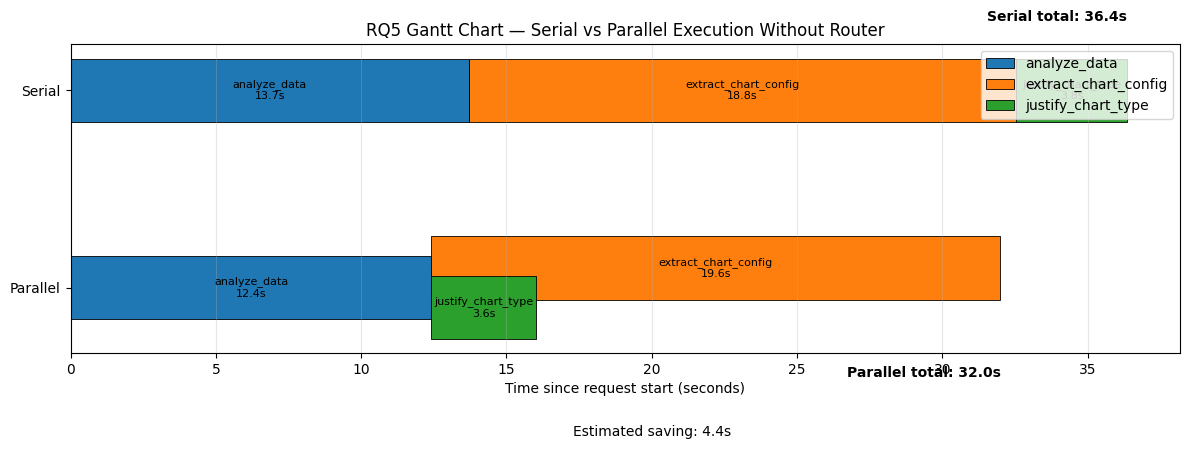

Saved: rq5_gantt_outputs/rq5_gantt_without_router.png


PosixPath('rq5_gantt_outputs/rq5_gantt_without_router.png')

In [6]:
# ============================================================
# CELL 6 — Gantt chart WITHOUT router
# ============================================================

plot_gantt(
    without_router_gantt,
    title="RQ5 Gantt Chart — Serial vs Parallel Execution Without Router",
    output_name="rq5_gantt_without_router.png",
)


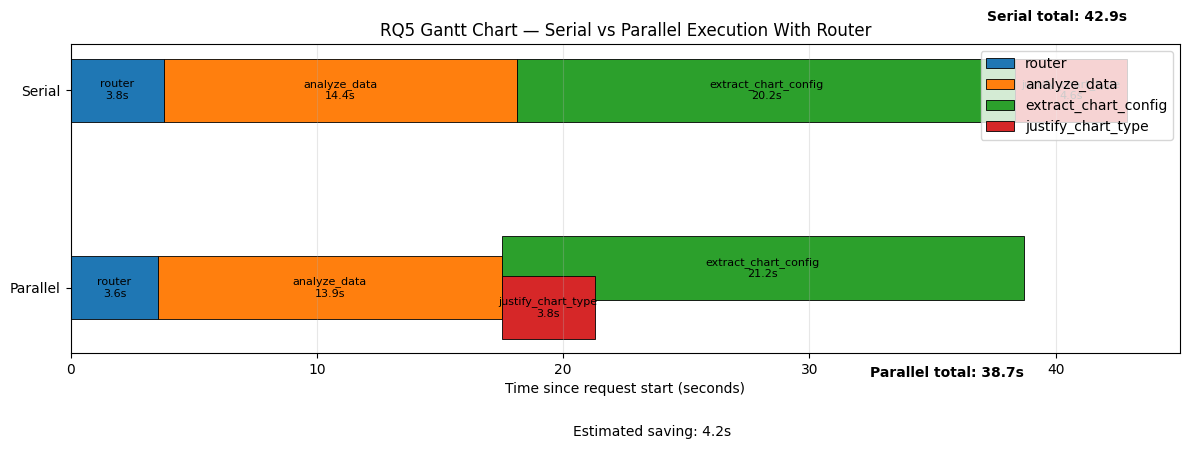

Saved: rq5_gantt_outputs/rq5_gantt_with_router.png


PosixPath('rq5_gantt_outputs/rq5_gantt_with_router.png')

In [7]:
# ============================================================
# CELL 7 — Gantt chart WITH router
# ============================================================

plot_gantt(
    with_router_gantt,
    title="RQ5 Gantt Chart — Serial vs Parallel Execution With Router",
    output_name="rq5_gantt_with_router.png",
)


In [8]:
# ============================================================
# CELL 8 — Critical path summary table
# ============================================================

def total_duration(gantt_df, path):
    return float(gantt_df[gantt_df["path"] == path]["end"].max())

critical_path_rows = []

for scenario_name, gantt_df in [
    ("without_router", without_router_gantt),
    ("with_router", with_router_gantt),
]:
    serial_total = total_duration(gantt_df, "Serial")
    parallel_total = total_duration(gantt_df, "Parallel")
    saving = serial_total - parallel_total
    reduction_pct = (saving / serial_total * 100) if serial_total else 0

    critical_path_rows.append({
        "scenario": scenario_name,
        "serial_total_s": serial_total,
        "parallel_total_s": parallel_total,
        "saving_s": saving,
        "reduction_pct": reduction_pct,
    })

critical_path_df = pd.DataFrame(critical_path_rows).round(2)
display(critical_path_df)

critical_path_df.to_csv(OUT_DIR / "rq5_gantt_critical_path_summary.csv", index=False)
print("Saved:", OUT_DIR / "rq5_gantt_critical_path_summary.csv")


,scenario,serial_total_s,parallel_total_s,saving_s,reduction_pct
0,without_router,36.36,32.00,4.36,12.00
1,with_router,42.91,38.73,4.18,9.74


Saved: rq5_gantt_outputs/rq5_gantt_critical_path_summary.csv


## Thesis explanation you can use

The Gantt charts show the difference between serial and parallel execution. In serial mode, the pipeline waits for `extract_chart_config` to finish before starting `justify_chart_type`. In parallel mode, both stages start after `analyze_data`, because both depend on the analysis output but not on each other.

The critical-path formula is:

```text
Serial without router   = analysis + config + type
Parallel without router = analysis + max(config, type)

Serial with router      = router + analysis + config + type
Parallel with router    = router + analysis + max(config, type)
```

Therefore, the maximum expected saving is approximately:

```text
min(config duration, type duration)
```

In this experiment, `justify_chart_type` is usually around 4 seconds, while `extract_chart_config` is much longer. This means parallelism can hide the chart-type justification time inside the longer chart-config generation time. That is why the median saving is expected to be only a few seconds, even though parallel execution can still reduce tail latency and improve throughput under concurrent load.
